> **Prerequisite:** Run `01`–`03` in the **same kernel session**, **or** run this notebook alone — the first code cell auto-loads `01`/`02` and minimal helpers from `03`.

# 04 — Split-half supplement

Internal validation figure and summary tables (requires moderated mediation from `01_statistics`).

In [1]:
"""Split-half supplement — auto-load prerequisites when run standalone."""

from __future__ import annotations

import json
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "data").is_dir():
    GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT = NOTEBOOK_DIR
else:
    GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT / "data"
FIGURES_DIR = GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT / "figures"
RESULTS_DIR = GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT / "results" / "split_half"
OUT_DIR = FIGURES_DIR
ANALYSIS_CSV = DATA_DIR / "analysis_ready.csv"


def _ensure_prerequisites() -> None:
    """Load 01/02 (and plotting helpers) when not already in this kernel."""
    if "MODERATED_MEDIATION_COLS" in globals() and "PANEL_C_MID" in globals():
        return
    nb_dir = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "notebooks"
    for nb_name in ("01_statistics.ipynb", "02_panel_plotting.ipynb"):
        nb_path = nb_dir / nb_name
        if not nb_path.is_file():
            raise RuntimeError(
                f"Missing prerequisite notebook: {nb_path}. "
                "Run 01_statistics.ipynb and 02_panel_plotting.ipynb first."
            )
        nb = json.loads(nb_path.read_text(encoding="utf-8"))
        for cell in nb["cells"]:
            if cell["cell_type"] != "code":
                continue
            src = "".join(cell["source"])
            lines = [ln for ln in src.splitlines() if not ln.strip().startswith("%")]
            code = "\n".join(lines).strip()
            if not code:
                continue
            exec(compile(code, f"{nb_name}", "exec"), globals())
    import matplotlib.gridspec as gridspec

    globals()["gridspec"] = gridspec


def load_analysis_df() -> pd.DataFrame:
    if not ANALYSIS_CSV.is_file():
        raise FileNotFoundError(f"Missing analysis table: {ANALYSIS_CSV}")
    return pd.read_csv(ANALYSIS_CSV)


def _in_notebook() -> bool:
    try:
        return get_ipython() is not None
    except NameError:
        return False


def _show_figure(fig: plt.Figure) -> None:
    if not _in_notebook():
        plt.show()
        return
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass
    from IPython.display import display

    display(fig)


_ensure_prerequisites()

W_COL = MODERATED_MEDIATION_COLS[2]
DISPERSION_LABEL = "SN gradient dispersion"
SPLIT_METHOD_LABEL = "SN gradient dispersion-median stratified 50/50 subject split"

SUPP_FIG_W_MM = 183
SUPP_FIG_H_MM = 89
SUPP_FIG_DPI = 600
SUPP_TEAL = PANEL_C_MID
SUPP_TEAL_LIGHT = "#B8E6DF"
SUPP_BLUE = BLUE
SUPP_BLUE_LIGHT = BLUE_LIGHT
SUPP_PANEL_LABEL_X_A = -0.06
SUPP_PANEL_LABEL_X_BC = -0.40
SUPP_LABEL_SHIFT_X = -0.08
SUPP_LABEL_SHIFT_Y = 0.045
SUPP_LABEL_SHIFT_X_RIGHT = 0.0
SUPP_BAR_SPACING = 1.5
SUPP_C_YTICK_LINE_SPACING = 0.9
SUPP_DIAMOND_MS = 5.5 * 0.75
SUPP_DIAMOND_S = 42 * 0.75
SUPP_FOREST_LW = 0.95 * 1.2
SUPP_BAR_H = 0.58 * 1.2 * 1.2 * 1.2
SUPP_C_WIDTH_SCALE = 0.95
SUPP_C_HEIGHT_SCALE = 1.05
SUPP_BAR = WONG[0]


def moderated_mediation_z_stats(
    df: pd.DataFrame, cols: list[str] | None = None
) -> dict[str, tuple[float, float]]:
    """Full-sample mean/std for fixed z-scoring in split-half validation."""
    cols = cols or MODERATED_MEDIATION_COLS
    raw = df[cols].dropna()
    return {c: (float(raw[c].mean()), float(raw[c].std(ddof=1))) for c in cols}


def fit_moderated_mediation_fixed_z(
    df: pd.DataFrame,
    z_stats: dict[str, tuple[float, float]],
    *,
    cols: list[str] | None = None,
    n_boot: int = 5000,
    seed: int = 42,
) -> dict:
    """Hayes Model 14 with z-scores anchored to full-sample z_stats."""
    cols = cols or MODERATED_MEDIATION_COLS
    raw = df[cols].dropna().copy()
    sub = raw.copy()
    for c in cols:
        mu, sd = z_stats[c]
        sub[c] = (sub[c] - mu) / sd if sd > 0 else 0.0
    x, m, w, y = (sub[c].values for c in cols)
    n = len(x)
    if n < 8:
        nan = float("nan")
        nan_ci = [nan, nan]
        return {
            "n": n,
            "a1": nan,
            "p_a1": nan,
            "ci_a1": nan_ci,
            "b1": nan,
            "b3": nan,
            "p_b1": nan,
            "p_b3": nan,
            "ci_b1": nan_ci,
            "ci_b3": nan_ci,
            "imm": nan,
            "imm_ci": nan_ci,
            "ind_high": nan,
            "ind_low": nan,
            "ind_high_ci": nan_ci,
            "ind_low_ci": nan_ci,
            "r2_m": nan,
            "r2_y": nan,
            "f_p_m": nan,
            "f_p_y": nan,
            "sub_z": sub,
            "raw": raw,
        }
    m_m = OLS(m, add_constant(x)).fit()
    a1 = float(m_m.params[1])
    p_a1 = float(m_m.pvalues[1])
    ci_a1 = np.asarray(m_m.conf_int())[1].tolist()
    design_y = np.column_stack([np.ones(n), m, w, m * w, x])
    m_y = OLS(y, design_y).fit()
    b1, b2, b3 = (float(m_y.params[i]) for i in range(1, 4))
    p_b1, p_b3 = float(m_y.pvalues[1]), float(m_y.pvalues[3])
    ci_y = np.asarray(m_y.conf_int())
    ci_b1, ci_b3 = ci_y[1].tolist(), ci_y[3].tolist()
    imm = a1 * b3
    ind_high = a1 * (b1 - b3)
    ind_low = a1 * (b1 + b3)
    boot_imm: list[float] = []
    boot_ind_high: list[float] = []
    boot_ind_low: list[float] = []
    if n_boot > 0:
        rs = np.random.RandomState(seed)
        for _ in range(n_boot):
            idx = rs.randint(0, n, n)
            try:
                ab = OLS(m[idx], add_constant(x[idx])).fit().params[1]
                gp = OLS(
                    y[idx],
                    add_constant(np.column_stack([m[idx], w[idx], m[idx] * w[idx], x[idx]])),
                ).fit().params
                bb1, bb3 = float(gp[1]), float(gp[3])
                boot_imm.append(ab * bb3)
                boot_ind_high.append(ab * (bb1 - bb3))
                boot_ind_low.append(ab * (bb1 + bb3))
            except Exception:
                pass
    imm_ci = np.percentile(boot_imm, [2.5, 97.5]).tolist() if boot_imm else [np.nan, np.nan]
    ind_high_ci = (
        np.percentile(boot_ind_high, [2.5, 97.5]).tolist() if boot_ind_high else [np.nan, np.nan]
    )
    ind_low_ci = (
        np.percentile(boot_ind_low, [2.5, 97.5]).tolist() if boot_ind_low else [np.nan, np.nan]
    )
    return {
        "n": n,
        "a1": a1,
        "p_a1": p_a1,
        "ci_a1": ci_a1,
        "b1": b1,
        "b3": b3,
        "p_b1": p_b1,
        "p_b3": p_b3,
        "ci_b1": ci_b1,
        "ci_b3": ci_b3,
        "imm": imm,
        "imm_ci": imm_ci,
        "ind_high": ind_high,
        "ind_low": ind_low,
        "ind_high_ci": ind_high_ci,
        "ind_low_ci": ind_low_ci,
        "r2_m": float(m_m.rsquared),
        "r2_y": float(m_y.rsquared),
        "f_p_m": float(m_m.f_pvalue),
        "f_p_y": float(m_y.f_pvalue),
        "sub_z": sub,
        "raw": raw,
    }


def _ci_excludes_zero(ci: list[float] | np.ndarray) -> bool:
    lo, hi = float(ci[0]), float(ci[1])
    if np.isnan(lo) or np.isnan(hi):
        return False
    return lo > 0 or hi < 0


def _subject_w_series(subj_df: pd.DataFrame, w_col: str = W_COL) -> pd.Series:
    return subj_df.groupby("subject")[w_col].first()


def _stratified_subject_halves_by_dispersion(
    subjects: np.ndarray,
    dispersion_by_subj: pd.Series,
    seed: int,
    *,
    dispersion_cut: float | None = None,
) -> tuple[np.ndarray, np.ndarray, dict]:
    """50/50 subject split with SN gradient dispersion-median stratification."""
    dispersion_cut = float(dispersion_by_subj.median()) if dispersion_cut is None else dispersion_cut
    low = [s for s in subjects if dispersion_by_subj.get(s, np.nan) <= dispersion_cut]
    high = [s for s in subjects if dispersion_by_subj.get(s, np.nan) > dispersion_cut]
    rng = np.random.RandomState(seed)
    h1_list, h2_list = [], []
    for pool in (low, high):
        pool = list(pool)
        rng.shuffle(pool)
        mid = len(pool) // 2
        h1_list.extend(pool[:mid])
        h2_list.extend(pool[mid:])
    meta = {
        "split_method": SPLIT_METHOD_LABEL,
        "dispersion_col": W_COL,
        "dispersion_median_cut_raw": dispersion_cut,
        "n_subjects_low_dispersion_stratum": int(len(low)),
        "n_subjects_high_dispersion_stratum": int(len(high)),
    }
    return np.asarray(h1_list), np.asarray(h2_list), meta


def _half_dispersion_balance(
    df: pd.DataFrame,
    subjects: np.ndarray | set,
    dispersion_cut: float,
    z_stats: dict[str, tuple[float, float]],
    *,
    dispersion_col: str = W_COL,
) -> dict:
    subj_set = set(subjects)
    disp_raw = df[df["subject"].isin(subj_set)].groupby("subject")[dispersion_col].first()
    mu, sd = z_stats[dispersion_col]
    disp_z = (disp_raw - mu) / sd if sd > 0 else disp_raw * 0.0
    return {
        "n": int(len(disp_raw)),
        "dispersion_mean_raw": float(disp_raw.mean()),
        "dispersion_sd_raw": float(disp_raw.std(ddof=1)) if len(disp_raw) > 1 else float("nan"),
        "dispersion_mean_z": float(disp_z.mean()),
        "n_low_dispersion_stratum": int((disp_raw <= dispersion_cut).sum()),
        "n_high_dispersion_stratum": int((disp_raw > dispersion_cut).sum()),
    }


def _distribution_stats(series: pd.Series) -> dict[str, float]:
    if series.empty:
        nan = float("nan")
        return {
            "mean": nan,
            "median": nan,
            "sd": nan,
            "q25": nan,
            "q75": nan,
            "q2_5": nan,
            "q97_5": nan,
            "min": nan,
            "max": nan,
        }
    return {
        "mean": float(series.mean()),
        "median": float(series.median()),
        "sd": float(series.std(ddof=1)),
        "q25": float(series.quantile(0.25)),
        "q75": float(series.quantile(0.75)),
        "q2_5": float(series.quantile(0.025)),
        "q97_5": float(series.quantile(0.975)),
        "min": float(series.min()),
        "max": float(series.max()),
    }


def _build_repeated_distribution_table(repeated_df: pd.DataFrame) -> pd.DataFrame:
    specs = [
        ("a1", "a1_half1", "a1_half2"),
        ("b1", "b1_half1", "b1_half2"),
        ("b3", "b3_half1", "b3_half2"),
        ("imm", "imm_half1", "imm_half2"),
        ("ind_high", "ind_high_half1", "ind_high_half2"),
        ("ind_low", "ind_low_half1", "ind_low_half2"),
    ]
    rows: list[dict] = []
    for param, c1, c2 in specs:
        for half, col in (("half1", c1), ("half2", c2)):
            stats = _distribution_stats(repeated_df[col])
            rows.append({"parameter": param, "half": half, **stats})
    return pd.DataFrame(rows)


def _build_repeated_stability_table(
    repeated_df: pd.DataFrame,
    med_full: dict,
    *,
    n_repeated: int,
    seed: int,
    single_rep: dict,
    split_meta: dict,
) -> pd.DataFrame:
    def _rate(col: str) -> float:
        return float(repeated_df[col].mean()) if len(repeated_df) else float("nan")

    imm_full = float(med_full["imm"])
    imm_ci_lo, imm_ci_hi = (float(med_full["imm_ci"][0]), float(med_full["imm_ci"][1]))
    imm_h1 = repeated_df["imm_half1"]
    imm_h2 = repeated_df["imm_half2"]
    h1_median = float(imm_h1.median()) if len(imm_h1) else float("nan")
    h2_median = float(imm_h2.median()) if len(imm_h2) else float("nan")

    if abs(imm_full) > 1e-12:
        rel_h1 = (imm_h1 - imm_full).abs() / abs(imm_full)
        rel_h2 = (imm_h2 - imm_full).abs() / abs(imm_full)
        rel_pair = (rel_h1 + rel_h2) / 2.0
        rel_dev_median = float(rel_pair.median())
        rel_dev_q75 = float(rel_pair.quantile(0.75))
        rel_within_50pct = float((rel_pair <= 0.5).mean())
    else:
        rel_dev_median = rel_dev_q75 = rel_within_50pct = float("nan")

    imm_corr = (
        float(repeated_df["imm_half1"].corr(repeated_df["imm_half2"]))
        if len(repeated_df) > 1
        else float("nan")
    )

    rows = [
        {"section": "design", "metric": "split_method", "value": split_meta["split_method"]},
        {"section": "design", "metric": "dispersion_stratum_variable", "value": split_meta["dispersion_col"]},
        {"section": "design", "metric": "dispersion_median_cut_raw", "value": split_meta["dispersion_median_cut_raw"]},
        {
            "section": "design",
            "metric": "n_subjects_low_dispersion_stratum",
            "value": split_meta["n_subjects_low_dispersion_stratum"],
        },
        {
            "section": "design",
            "metric": "n_subjects_high_dispersion_stratum",
            "value": split_meta["n_subjects_high_dispersion_stratum"],
        },
        {"section": "design", "metric": "n_random_splits", "value": n_repeated},
        {"section": "design", "metric": "single_split_seed", "value": seed},
        {"section": "single_split", "metric": "imm_same_sign", "value": single_rep["imm_same_sign"]},
        {"section": "single_split", "metric": "imm_both_sig", "value": single_rep["imm_both_sig"]},
        {"section": "single_split", "metric": "a1_same_sign", "value": single_rep["a1_same_sign"]},
        {"section": "single_split", "metric": "b1_same_sign", "value": single_rep["b1_same_sign"]},
        {"section": "single_split", "metric": "b3_same_sign", "value": single_rep["b3_same_sign"]},
        {"section": "single_split", "metric": "ind_high_same_sign", "value": single_rep["ind_high_same_sign"]},
        {"section": "single_split", "metric": "ind_low_same_sign", "value": single_rep["ind_low_same_sign"]},
        {"section": "single_split", "metric": "ind_high_both_sig", "value": single_rep["ind_high_both_sig"]},
        {"section": "single_split", "metric": "ind_low_both_sig", "value": single_rep["ind_low_both_sig"]},
        {"section": "sign_concordance", "metric": "imm_same_sign_rate", "value": _rate("imm_same_sign")},
        {"section": "sign_concordance", "metric": "a1_same_sign_rate", "value": _rate("a1_same_sign")},
        {"section": "sign_concordance", "metric": "b1_same_sign_rate", "value": _rate("b1_same_sign")},
        {"section": "sign_concordance", "metric": "b3_same_sign_rate", "value": _rate("b3_same_sign")},
        {"section": "sign_concordance", "metric": "ind_high_same_sign_rate", "value": _rate("ind_high_same_sign")},
        {"section": "sign_concordance", "metric": "ind_low_same_sign_rate", "value": _rate("ind_low_same_sign")},
        {"section": "sign_concordance", "metric": "imm_same_sign_as_full_rate", "value": _rate("imm_same_sign_as_full")},
        {"section": "full_sample", "metric": "imm_point_estimate", "value": imm_full},
        {"section": "full_sample", "metric": "imm_ci_lo", "value": imm_ci_lo},
        {"section": "full_sample", "metric": "imm_ci_hi", "value": imm_ci_hi},
        {"section": "full_sample", "metric": "full_ci_covers_repeated_imm_half1_median", "value": imm_ci_lo <= h1_median <= imm_ci_hi},
        {"section": "full_sample", "metric": "full_ci_covers_repeated_imm_half2_median", "value": imm_ci_lo <= h2_median <= imm_ci_hi},
        {"section": "magnitude_stability", "metric": "imm_half1_median", "value": h1_median},
        {"section": "magnitude_stability", "metric": "imm_half1_q25", "value": _distribution_stats(imm_h1)["q25"]},
        {"section": "magnitude_stability", "metric": "imm_half1_q75", "value": _distribution_stats(imm_h1)["q75"]},
        {"section": "magnitude_stability", "metric": "imm_half1_sd", "value": _distribution_stats(imm_h1)["sd"]},
        {"section": "magnitude_stability", "metric": "imm_half1_q2_5", "value": _distribution_stats(imm_h1)["q2_5"]},
        {"section": "magnitude_stability", "metric": "imm_half1_q97_5", "value": _distribution_stats(imm_h1)["q97_5"]},
        {"section": "magnitude_stability", "metric": "imm_half2_median", "value": h2_median},
        {"section": "magnitude_stability", "metric": "imm_half2_q25", "value": _distribution_stats(imm_h2)["q25"]},
        {"section": "magnitude_stability", "metric": "imm_half2_q75", "value": _distribution_stats(imm_h2)["q75"]},
        {"section": "magnitude_stability", "metric": "imm_half2_sd", "value": _distribution_stats(imm_h2)["sd"]},
        {"section": "magnitude_stability", "metric": "imm_half2_q2_5", "value": _distribution_stats(imm_h2)["q2_5"]},
        {"section": "magnitude_stability", "metric": "imm_half2_q97_5", "value": _distribution_stats(imm_h2)["q97_5"]},
        {"section": "magnitude_stability", "metric": "imm_half1_half2_correlation", "value": imm_corr},
        {"section": "magnitude_stability", "metric": "median_relative_deviation_from_full_imm", "value": rel_dev_median},
        {"section": "magnitude_stability", "metric": "q75_relative_deviation_from_full_imm", "value": rel_dev_q75},
        {"section": "magnitude_stability", "metric": "splits_within_50pct_of_full_imm_rate", "value": rel_within_50pct},
    ]
    return pd.DataFrame(rows)


def _half_replication_metrics(h1: dict, h2: dict) -> dict[str, bool]:
    def same_sign(k: str) -> bool:
        return np.sign(h1[k]) == np.sign(h2[k]) and not (np.isnan(h1[k]) or np.isnan(h2[k]))

    return {
        "a1_same_sign": same_sign("a1"),
        "b1_same_sign": same_sign("b1"),
        "b3_same_sign": same_sign("b3"),
        "imm_same_sign": same_sign("imm"),
        "ind_high_same_sign": same_sign("ind_high"),
        "ind_low_same_sign": same_sign("ind_low"),
        "imm_both_sig": _ci_excludes_zero(h1["imm_ci"]) and _ci_excludes_zero(h2["imm_ci"]),
        "ind_high_both_sig": _ci_excludes_zero(h1["ind_high_ci"]) and _ci_excludes_zero(h2["ind_high_ci"]),
        "ind_low_both_sig": _ci_excludes_zero(h1["ind_low_ci"]) and _ci_excludes_zero(h2["ind_low_ci"]),
    }


def _med_to_supplement_row(label: str, med: dict) -> dict:
    imm_lo, imm_hi = med["imm_ci"]
    ih_lo, ih_hi = med["ind_high_ci"]
    il_lo, il_hi = med["ind_low_ci"]
    return {
        "sample": label,
        "n": int(med["n"]),
        "a1": med["a1"],
        "b1": med["b1"],
        "b3": med["b3"],
        "imm": med["imm"],
        "imm_ci_lo": imm_lo,
        "imm_ci_hi": imm_hi,
        "imm_ci_excludes_zero": _ci_excludes_zero(med["imm_ci"]),
        "ind_high_fidelity_minus1sd": med["ind_high"],
        "ind_high_ci_lo": ih_lo,
        "ind_high_ci_hi": ih_hi,
        "ind_low_fidelity_plus1sd": med["ind_low"],
        "ind_low_ci_lo": il_lo,
        "ind_low_ci_hi": il_hi,
    }


def split_half_validate_panel_e(
    df: pd.DataFrame,
    *,
    seed: int = 42,
    n_repeated: int = 1000,
    n_boot: int = 5000,
) -> dict:
    """Split-half internal validation for panel e (Hayes Model 14; moderator = SN gradient dispersion)."""
    cols = MODERATED_MEDIATION_COLS
    if "subject" not in df.columns:
        raise KeyError("df must contain a 'subject' column for subject-level split-half.")
    subj_df = df[["subject"] + cols].dropna()
    subjects = subj_df["subject"].unique()
    if len(subjects) < 16:
        raise ValueError(f"Need at least 16 subjects for split-half; got {len(subjects)}.")

    dispersion_by_subj = _subject_w_series(subj_df, W_COL)
    dispersion_cut = float(dispersion_by_subj.median())
    z_stats = moderated_mediation_z_stats(df, cols)
    med_full = fit_moderated_mediation(df)

    s1, s2, split_meta = _stratified_subject_halves_by_dispersion(
        subjects, dispersion_by_subj, seed, dispersion_cut=dispersion_cut
    )
    g1, g2 = set(s1), set(s2)
    med_h1 = fit_moderated_mediation_fixed_z(df[df["subject"].isin(g1)], z_stats, n_boot=n_boot, seed=seed)
    med_h2 = fit_moderated_mediation_fixed_z(
        df[df["subject"].isin(g2)], z_stats, n_boot=n_boot, seed=seed + 1
    )
    single_rep = _half_replication_metrics(med_h1, med_h2)
    balance_table = pd.DataFrame(
        [
            {"half": "half1", **_half_dispersion_balance(df, g1, dispersion_cut, z_stats)},
            {"half": "half2", **_half_dispersion_balance(df, g2, dispersion_cut, z_stats)},
            {"half": "full", **_half_dispersion_balance(df, set(subjects), dispersion_cut, z_stats)},
        ]
    )

    repeated_rows: list[dict] = []
    full_imm_sign = np.sign(med_full["imm"])
    for i in range(n_repeated):
        h1_subj, h2_subj, _ = _stratified_subject_halves_by_dispersion(
            subjects, dispersion_by_subj, seed + 1000 + i, dispersion_cut=dispersion_cut
        )
        mh1 = fit_moderated_mediation_fixed_z(
            df[df["subject"].isin(set(h1_subj))], z_stats, n_boot=0, seed=0
        )
        mh2 = fit_moderated_mediation_fixed_z(
            df[df["subject"].isin(set(h2_subj))], z_stats, n_boot=0, seed=0
        )
        rep = _half_replication_metrics(mh1, mh2)
        repeated_rows.append(
            {
                "split_id": i,
                "seed": seed + 1000 + i,
                "n_half1": mh1["n"],
                "n_half2": mh2["n"],
                "imm_half1": mh1["imm"],
                "imm_half2": mh2["imm"],
                "a1_half1": mh1["a1"],
                "a1_half2": mh2["a1"],
                "b1_half1": mh1["b1"],
                "b1_half2": mh2["b1"],
                "b3_half1": mh1["b3"],
                "b3_half2": mh2["b3"],
                "ind_high_half1": mh1["ind_high"],
                "ind_high_half2": mh2["ind_high"],
                "ind_low_half1": mh1["ind_low"],
                "ind_low_half2": mh2["ind_low"],
                "imm_same_sign": rep["imm_same_sign"],
                "a1_same_sign": rep["a1_same_sign"],
                "b1_same_sign": rep["b1_same_sign"],
                "b3_same_sign": rep["b3_same_sign"],
                "ind_high_same_sign": rep["ind_high_same_sign"],
                "ind_low_same_sign": rep["ind_low_same_sign"],
                "imm_same_sign_as_full": np.sign(mh1["imm"]) == full_imm_sign
                and np.sign(mh2["imm"]) == full_imm_sign,
            }
        )
    repeated_df = pd.DataFrame(repeated_rows)
    distribution_table = _build_repeated_distribution_table(repeated_df)
    stability_table = _build_repeated_stability_table(
        repeated_df,
        med_full,
        n_repeated=n_repeated,
        seed=seed,
        single_rep=single_rep,
        split_meta=split_meta,
    )

    summary_table = pd.DataFrame(
        [
            _med_to_supplement_row("Full sample (panel e)", med_full),
            _med_to_supplement_row(f"Dispersion-stratified half 1 (seed={seed})", med_h1),
            _med_to_supplement_row(f"Dispersion-stratified half 2 (seed={seed})", med_h2),
        ]
    )

    return {
        "cols": cols,
        "z_stats": z_stats,
        "n_subjects": len(subjects),
        "split_meta": split_meta,
        "full": med_full,
        "single": {
            "seed": seed,
            "half1": med_h1,
            "half2": med_h2,
            "replication": single_rep,
            "balance": balance_table,
        },
        "repeated": {
            "n_splits": n_repeated,
            "records": repeated_df,
            "distribution": distribution_table,
            "stability": stability_table,
        },
        "summary_table": summary_table,
        "balance_table": balance_table,
        "distribution_table": distribution_table,
        "stability_table": stability_table,
    }


def _format_ci(val: float, lo: float, hi: float) -> str:
    if any(np.isnan(x) for x in (val, lo, hi)):
        return "NA"
    return f"{val:.3f} [{lo:.3f}, {hi:.3f}]"


def print_split_half_supplement(result: dict) -> None:
    """Print supplement tables for panel e split-half validation."""
    meta = result["split_meta"]
    print("=" * 80)
    print("panel e split-half validation (Hayes Model 14; moderator = SN gradient dispersion)")
    print(f"Subjects: {result['n_subjects']} | Single split seed: {result['single']['seed']}")
    print(
        f"Split method: {meta['split_method']} | "
        f"Dispersion cut (raw median): {meta['dispersion_median_cut_raw']:.4f}"
    )
    print(
        "Dispersion strata counts (low/high): "
        f"{meta['n_subjects_low_dispersion_stratum']} / {meta['n_subjects_high_dispersion_stratum']}"
    )
    print(f"Repeated dispersion-stratified splits: {result['repeated']['n_splits']}")
    print("=" * 80)

    tbl = result["summary_table"].copy()
    tbl["imm_95ci"] = [
        _format_ci(r.imm, r.imm_ci_lo, r.imm_ci_hi) for r in tbl.itertuples(index=False)
    ]
    tbl["ind_high_95ci"] = [
        _format_ci(r.ind_high_fidelity_minus1sd, r.ind_high_ci_lo, r.ind_high_ci_hi)
        for r in tbl.itertuples(index=False)
    ]
    tbl["ind_low_95ci"] = [
        _format_ci(r.ind_low_fidelity_plus1sd, r.ind_low_ci_lo, r.ind_low_ci_hi)
        for r in tbl.itertuples(index=False)
    ]
    show_cols = [
        "sample", "n", "a1", "b1", "b3", "imm_95ci", "ind_high_95ci", "ind_low_95ci",
    ]
    print("\nTable S1 - Split-half moderated mediation (SN gradient dispersion-stratified; bootstrap CI per half):\n")
    print(tbl[show_cols].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    print(
        "\nTable S2 - SN gradient dispersion balance across halves "
        "(single split; raw + z using full-sample stats):\n"
    )
    print(result["balance_table"].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    rep = result["single"]["replication"]
    print("\nTable S3 - Single-split replication checks:")
    for k, v in rep.items():
        print(f"  {k}: {v}")

    dist = result["distribution_table"].copy()
    dist["iqr"] = dist.apply(lambda r: f"[{r.q25:.3f}, {r.q75:.3f}]", axis=1)
    dist["empirical_95"] = dist.apply(lambda r: f"[{r.q2_5:.3f}, {r.q97_5:.3f}]", axis=1)
    dist_show = dist[["parameter", "half", "median", "iqr", "sd", "empirical_95", "min", "max"]]
    print(
        "\nTable S4 - Repeated SN gradient dispersion-stratified splits: effect-size distributions "
        "(point estimates; median, IQR, SD, 2.5-97.5%):\n"
    )
    print(dist_show.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    stab = result["stability_table"]
    for section in ("design", "single_split", "sign_concordance", "full_sample", "magnitude_stability"):
        sub = stab[stab["section"] == section]
        if sub.empty:
            continue
        print(f"\nTable S5 - Stability summary ({section}):\n")
        print(sub[["metric", "value"]].to_string(index=False))

    print("\nNotes:")
    print(
        "  - Subjects were split 50/50 WITHIN each SN gradient dispersion stratum "
        "(median split; not by fidelity group assignment)."
    )
    print(
        "  - High-fidelity indirect effect: dispersion = -1 SD; "
        "low fidelity: dispersion = +1 SD."
    )
    print("  - Z-scores in split halves use full-sample mean/std (not within-half).")
    print("  - Repeated-split rates = fraction of splits meeting the criterion.")
    print("  - Relative deviation = mean(|IMM_half - IMM_full| / |IMM_full|) across halves.")
    print("=" * 80)


def save_split_half_supplement(
    result: dict,
    out_dir: Path | None = None,
    *,
    stem: str = "panel_e_split_half",
) -> list[Path]:
    """Save supplement CSVs for panel e split-half validation."""
    out_dir = out_dir or RESULTS_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = [
        out_dir / f"{stem}_summary.csv",
        out_dir / f"{stem}_balance.csv",
        out_dir / f"{stem}_distribution.csv",
        out_dir / f"{stem}_stability.csv",
        out_dir / f"{stem}_repeated_splits.csv",
    ]
    result["summary_table"].to_csv(paths[0], index=False)
    result["balance_table"].to_csv(paths[1], index=False)
    result["distribution_table"].to_csv(paths[2], index=False)
    result["stability_table"].to_csv(paths[3], index=False)
    result["repeated"]["records"].to_csv(paths[4], index=False)
    print("Saved supplement CSVs:")
    for p in paths:
        print(f"  {p}")
    return paths


def _hide_y_spine_and_tick_marks(ax: plt.Axes) -> None:
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0, width=0, pad=5, colors=TEXT)


def _scale_axes_bbox(
    ax: plt.Axes,
    *,
    width_scale: float = 1.0,
    height_scale: float = 1.0,
    anchor: str = "bottom-center",
) -> None:
    pos = ax.get_position()
    new_w = pos.width * width_scale
    new_h = pos.height * height_scale
    cx = pos.x0 + pos.width / 2
    cy = pos.y0 + pos.height / 2
    if anchor == "bottom-center":
        new_x0 = cx - new_w / 2
        new_y0 = pos.y0
    elif anchor == "center":
        new_x0 = cx - new_w / 2
        new_y0 = cy - new_h / 2
    else:
        new_x0, new_y0 = pos.x0, pos.y0
    ax.set_position([new_x0, new_y0, new_w, new_h])


def _clip_violin_to_upper_half(ax: plt.Axes, body, y_center: float, xlim: tuple[float, float]) -> None:
    x0, x1 = xlim
    clip = mpatches.Rectangle(
        (x0 - 1.0, y_center),
        (x1 - x0) + 2.0,
        10.0,
        transform=ax.transData,
        visible=False,
    )
    ax.add_patch(clip)
    body.set_clip_path(clip)


def _place_supp_panel_label(
    ax: plt.Axes,
    letter: str,
    *,
    x: float | None = None,
    y: float | None = None,
    va: str = "top",
) -> mpl.text.Text:
    if x is not None:
        label_x = x
    elif letter == "a":
        label_x = SUPP_PANEL_LABEL_X_A
    else:
        label_x = SUPP_PANEL_LABEL_X_BC
    label_y = 0.98 + SUPP_LABEL_SHIFT_Y if y is None else y
    return ax.text(
        label_x + SUPP_LABEL_SHIFT_X + SUPP_LABEL_SHIFT_X_RIGHT,
        label_y,
        letter,
        transform=ax.transAxes,
        fontsize=FS_PANEL,
        fontweight="bold",
        va=va,
        ha="left",
        clip_on=False,
    )


def _align_supp_a_label_bottom_to_b(
    fig: plt.Figure,
    ax_a: plt.Axes,
    text_a: mpl.text.Text,
    text_b: mpl.text.Text,
) -> None:
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bb_b = text_b.get_window_extent(renderer)
    y_bottom_fig = fig.transFigure.inverted().transform((bb_b.x0, bb_b.y0))[1]
    pos_a = ax_a.get_position()
    text_a.set_y((y_bottom_fig - pos_a.y0) / pos_a.height)
    text_a.set_verticalalignment("bottom")


def _align_supp_label_left_to_reference(
    fig: plt.Figure,
    ax: plt.Axes,
    text: mpl.text.Text,
    text_ref: mpl.text.Text,
) -> None:
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bb_ref = text_ref.get_window_extent(renderer)
    x_left_fig = fig.transFigure.inverted().transform((bb_ref.x0, bb_ref.y0))[0]
    pos = ax.get_position()
    text.set_x((x_left_fig - pos.x0) / pos.width)
    text.set_horizontalalignment("left")


def _style_supp_xaxis_like_panel_a(
    ax: plt.Axes,
    *,
    xlim: tuple[float, float],
    x_step: float,
    draw_zero: bool = True,
) -> None:
    ax.set_xlim(xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + x_step * 0.5, x_step))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", pad=4, length=3.5, width=0.75, colors=TEXT)
    if draw_zero and xlim[0] <= 0 <= xlim[1]:
        ax.axvline(0, color=TEXT, lw=0.6, zorder=2)


def _style_supp_yaxis_like_panel_a(ax: plt.Axes) -> None:
    _hide_y_spine_and_tick_marks(ax)


def _plot_supp_forest_row(
    ax: plt.Axes,
    yi: float,
    est: float,
    ci: list[float] | np.ndarray,
    col: str,
    *,
    ms: float = SUPP_DIAMOND_MS,
    lw: float = SUPP_FOREST_LW,
) -> None:
    lo, hi = float(ci[0]), float(ci[1])
    ax.errorbar(
        est,
        yi,
        xerr=[[est - lo], [hi - est]],
        fmt="D",
        ms=ms,
        mew=0.6,
        color=col,
        markerfacecolor=col,
        markeredgecolor=col,
        ecolor=col,
        capsize=0,
        lw=lw,
        zorder=3,
    )


def _stab_metric(stability_table: pd.DataFrame, metric: str, section: str = "sign_concordance") -> float:
    sub = stability_table[(stability_table["section"] == section) & (stability_table["metric"] == metric)]
    if sub.empty:
        return float("nan")
    return float(sub["value"].iloc[0])


def build_split_half_supplement_figure(result: dict) -> plt.Figure:
    """Supplement figure: IMM stability across dispersion-stratified split-half validation."""
    repeated_df = result["repeated"]["records"]
    med_full = result["full"]
    med_h1 = result["single"]["half1"]
    med_h2 = result["single"]["half2"]
    stab = result["stability_table"]

    imm_h1 = repeated_df["imm_half1"].values
    imm_h2 = repeated_df["imm_half2"].values
    imm_full = float(med_full["imm"])
    imm_ci_lo, imm_ci_hi = float(med_full["imm_ci"][0]), float(med_full["imm_ci"][1])

    w_in = SUPP_FIG_W_MM / 25.4
    h_in = SUPP_FIG_H_MM / 25.4
    fig = plt.figure(figsize=(w_in, h_in), facecolor="white", dpi=SUPP_FIG_DPI)
    gs = gridspec.GridSpec(
        2,
        2,
        figure=fig,
        width_ratios=[1.35, 1.0],
        height_ratios=[1.0, 1.0],
        wspace=0.42,
        hspace=0.48,
    )
    ax_a = fig.add_subplot(gs[:, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 1])

    a_xlim = (-0.2, 0.6)
    vp = ax_a.violinplot(
        [imm_h1, imm_h2],
        positions=[2, 1],
        vert=False,
        widths=0.62,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    fill_cols = [SUPP_TEAL_LIGHT, SUPP_BLUE_LIGHT]
    edge_cols = [SUPP_TEAL, SUPP_BLUE]
    for i, (body, y_center) in enumerate(zip(vp["bodies"], (2, 1), strict=False)):
        body.set_facecolor(fill_cols[i])
        body.set_edgecolor(edge_cols[i])
        body.set_alpha(0.92)
        body.set_linewidth(0.9)
        _clip_violin_to_upper_half(ax_a, body, y_center, a_xlim)

    rng = np.random.RandomState(0)
    for vals, ypos, col in ((imm_h1, 2, SUPP_TEAL), (imm_h2, 1, SUPP_BLUE)):
        jitter = rng.uniform(0.0, 0.11, size=len(vals))
        ax_a.scatter(vals, ypos + jitter, s=4, c=col, alpha=0.07, linewidths=0, zorder=1)

    for vals, ypos, col in ((imm_h1, 2, SUPP_TEAL), (imm_h2, 1, SUPP_BLUE)):
        q25, q50, q75 = np.percentile(vals, [25, 50, 75])
        ax_a.hlines(ypos, q25, q75, colors=col, linewidth=3.2, zorder=4)
        ax_a.scatter([q50], [ypos], s=36, c=col, edgecolors="white", linewidths=0.5, zorder=5)

    ax_a.axvspan(imm_ci_lo, imm_ci_hi, color=TEXT, alpha=0.07, zorder=0, label="95% CI")
    ax_a.axvline(imm_full, color=TEXT, lw=1.4, zorder=6, label="IMM")
    ax_a.scatter(
        [imm_full],
        [2.52],
        marker="D",
        s=SUPP_DIAMOND_S,
        c=TEXT,
        edgecolors="white",
        linewidths=0.45,
        zorder=7,
    )

    ax_a.set_yticks([1, 2])
    ax_a.set_yticklabels(["Half 2", "Half 1"], fontsize=FS_TICK)
    ax_a.set_xlabel("Index of Moderated Mediation (IMM)")
    ax_a.set_ylim(0.35, 2.75)
    _style_supp_xaxis_like_panel_a(ax_a, xlim=a_xlim, x_step=0.2, draw_zero=False)
    ax_a.axvline(0, color=NET_GRAY, ls=(0, (3.0, 3.0)), lw=0.75, zorder=0)
    _style_supp_yaxis_like_panel_a(ax_a)
    ax_a.legend(
        frameon=False,
        fontsize=FS_SMALL,
        loc="upper right",
        title="Full Sample",
        title_fontsize=FS_SMALL,
        handlelength=1.4,
    )

    forest_rows = [
        ("Full Sample", med_full["imm"], med_full["imm_ci"], TEXT, SUPP_DIAMOND_MS),
        ("Half 1", med_h1["imm"], med_h1["imm_ci"], SUPP_TEAL, SUPP_DIAMOND_MS),
        ("Half 2", med_h2["imm"], med_h2["imm_ci"], SUPP_BLUE, SUPP_DIAMOND_MS),
    ]
    y_pos = np.arange(len(forest_rows))[::-1]
    for yi, (label, est, ci, col, ms) in zip(y_pos, forest_rows, strict=False):
        _plot_supp_forest_row(ax_b, yi, float(est), ci, col, ms=ms)
    ax_b.axvline(0, color=TEXT, ls=(0, (4.0, 3.0)), lw=0.75, zorder=1)
    ax_b.set_yticks(y_pos)
    ax_b.set_yticklabels([lab for lab, *_ in forest_rows], fontsize=FS_TICK)
    ax_b.set_xlabel("IMM (bootstrap 95% CI)")
    ax_b.set_ylim(-0.72, 2.72)
    ax_b.margins(y=0.08)
    _style_supp_xaxis_like_panel_a(ax_b, xlim=(-0.1, 0.7), x_step=0.2, draw_zero=False)
    _style_supp_yaxis_like_panel_a(ax_b)
    label_b = _place_supp_panel_label(ax_b, "b", x=SUPP_PANEL_LABEL_X_BC)

    concordance_specs = [
        ("IMM\n(Both Halves)", "imm_same_sign_rate"),
        ("IMM\n(VS. Full Sample)", "imm_same_sign_as_full_rate"),
        ("$b_3$ Interaction", "b3_same_sign_rate"),
        ("$a_1$ Path", "a1_same_sign_rate"),
        ("Indirect Effect\n(High Fidelity)", "ind_high_same_sign_rate"),
    ]
    rates = [_stab_metric(stab, m) for _, m in concordance_specs]
    labels_c = [s[0] for s in concordance_specs]
    y_c = np.arange(len(labels_c)) * SUPP_BAR_SPACING
    ax_c.barh(
        y_c,
        [r * 100 for r in rates],
        height=SUPP_BAR_H,
        color=SUPP_BAR,
        edgecolor="none",
        alpha=0.92,
    )
    ax_c.axvline(50, color=NET_GRAY, ls=(0, (2.5, 2.5)), lw=0.65, zorder=0)
    ax_c.axvline(90, color=SUPP_BAR, ls=(0, (2.0, 2.0)), lw=0.65, alpha=0.55, zorder=0)
    for yi, rate in zip(y_c, rates, strict=False):
        ax_c.text(
            min(rate * 100 + 1.8, 102),
            yi,
            f"{rate * 100:.1f}%",
            va="center",
            ha="left",
            fontsize=FS_SMALL,
            color=TEXT,
        )
    ax_c.set_yticks(y_c)
    ax_c.set_yticklabels(labels_c, fontsize=FS_TICK, linespacing=SUPP_C_YTICK_LINE_SPACING)
    ax_c.set_xlim(0, 108)
    ax_c.set_xticks([0, 25, 50, 75, 100])
    ax_c.set_xlabel("Sign Concordance Rate (%)")
    ax_c.spines["top"].set_visible(False)
    ax_c.spines["right"].set_visible(False)
    ax_c.tick_params(axis="both", pad=4, length=3.5, width=0.75, colors=TEXT)
    ax_c.invert_yaxis()
    label_c = _place_supp_panel_label(ax_c, "c", x=SUPP_PANEL_LABEL_X_BC)
    label_a = _place_supp_panel_label(ax_a, "a")
    _align_supp_a_label_bottom_to_b(fig, ax_a, label_a, label_b)

    fig.subplots_adjust(left=0.10, right=0.98, top=0.96, bottom=0.14, hspace=0.52)
    _scale_axes_bbox(
        ax_c,
        width_scale=SUPP_C_WIDTH_SCALE,
        height_scale=SUPP_C_HEIGHT_SCALE,
        anchor="bottom-center",
    )
    _align_supp_label_left_to_reference(fig, ax_c, label_c, label_b)
    return fig


def save_split_half_supplement_figure(
    fig: plt.Figure,
    out_dir: Path | None = None,
    *,
    stem: str = "figure_s_panel_e_split_half",
) -> list[Path]:
    """Export supplement split-half figure (PDF, SVG, PNG)."""
    out_dir = out_dir or OUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    saved: list[Path] = []
    for ext in ("pdf", "svg", "png", "eps"):
        path = out_dir / f"{stem}.{ext}"
        kw = {"dpi": SUPP_FIG_DPI, "bbox_inches": "tight", "facecolor": "white", "edgecolor": "none"}
        if ext == "eps":
            kw["format"] = "eps"
        fig.savefig(path, **kw)
        saved.append(path)
    print("Saved supplement figure:")
    for p in saved:
        print(f"  {p}")
    return saved


def plot_split_half_supplement(
    result: dict,
    *,
    show: bool | None = None,
    export: bool = True,
    out_dir: Path | None = None,
) -> plt.Figure:
    """Build (and optionally show/export) the split-half supplement figure."""
    if show is None:
        show = _in_notebook()
    fig = build_split_half_supplement_figure(result)
    if export:
        save_split_half_supplement_figure(fig, out_dir)
    if show:
        _show_figure(fig)
    elif not export:
        plt.close(fig)
    return fig


panel e split-half validation (Hayes Model 14; moderator = SN gradient dispersion)
Subjects: 43 | Single split seed: 42
Split method: SN gradient dispersion-median stratified 50/50 subject split | Dispersion cut (raw median): 0.0386
Dispersion strata counts (low/high): 22 / 21
Repeated dispersion-stratified splits: 1000

Table S1 - Split-half moderated mediation (SN gradient dispersion-stratified; bootstrap CI per half):

                                sample  n    a1     b1    b3              imm_95ci           ind_high_95ci           ind_low_95ci
                 Full sample (panel e) 43 0.327 -0.331 0.372  0.122 [0.001, 0.288] -0.230 [-0.477, -0.043]  0.013 [-0.160, 0.205]
Dispersion-stratified half 1 (seed=42) 21 0.320 -0.642 0.182 0.058 [-0.065, 0.357] -0.264 [-0.647, -0.010] -0.147 [-0.367, 0.235]
Dispersion-stratified half 2 (seed=42) 22 0.372 -0.086 0.563 0.209 [-0.161, 0.580]  -0.241 [-0.692, 0.166]  0.178 [-0.247, 0.625]

Table S2 - SN gradient dispersion balance across halv

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved supplement figure:
  d:\文件同步\文件\数据分析结果\data_code_figure\gradient_dispersion_mediate_moderate\figures\figure_s_panel_e_split_half.pdf
  d:\文件同步\文件\数据分析结果\data_code_figure\gradient_dispersion_mediate_moderate\figures\figure_s_panel_e_split_half.svg
  d:\文件同步\文件\数据分析结果\data_code_figure\gradient_dispersion_mediate_moderate\figures\figure_s_panel_e_split_half.png
  d:\文件同步\文件\数据分析结果\data_code_figure\gradient_dispersion_mediate_moderate\figures\figure_s_panel_e_split_half.eps


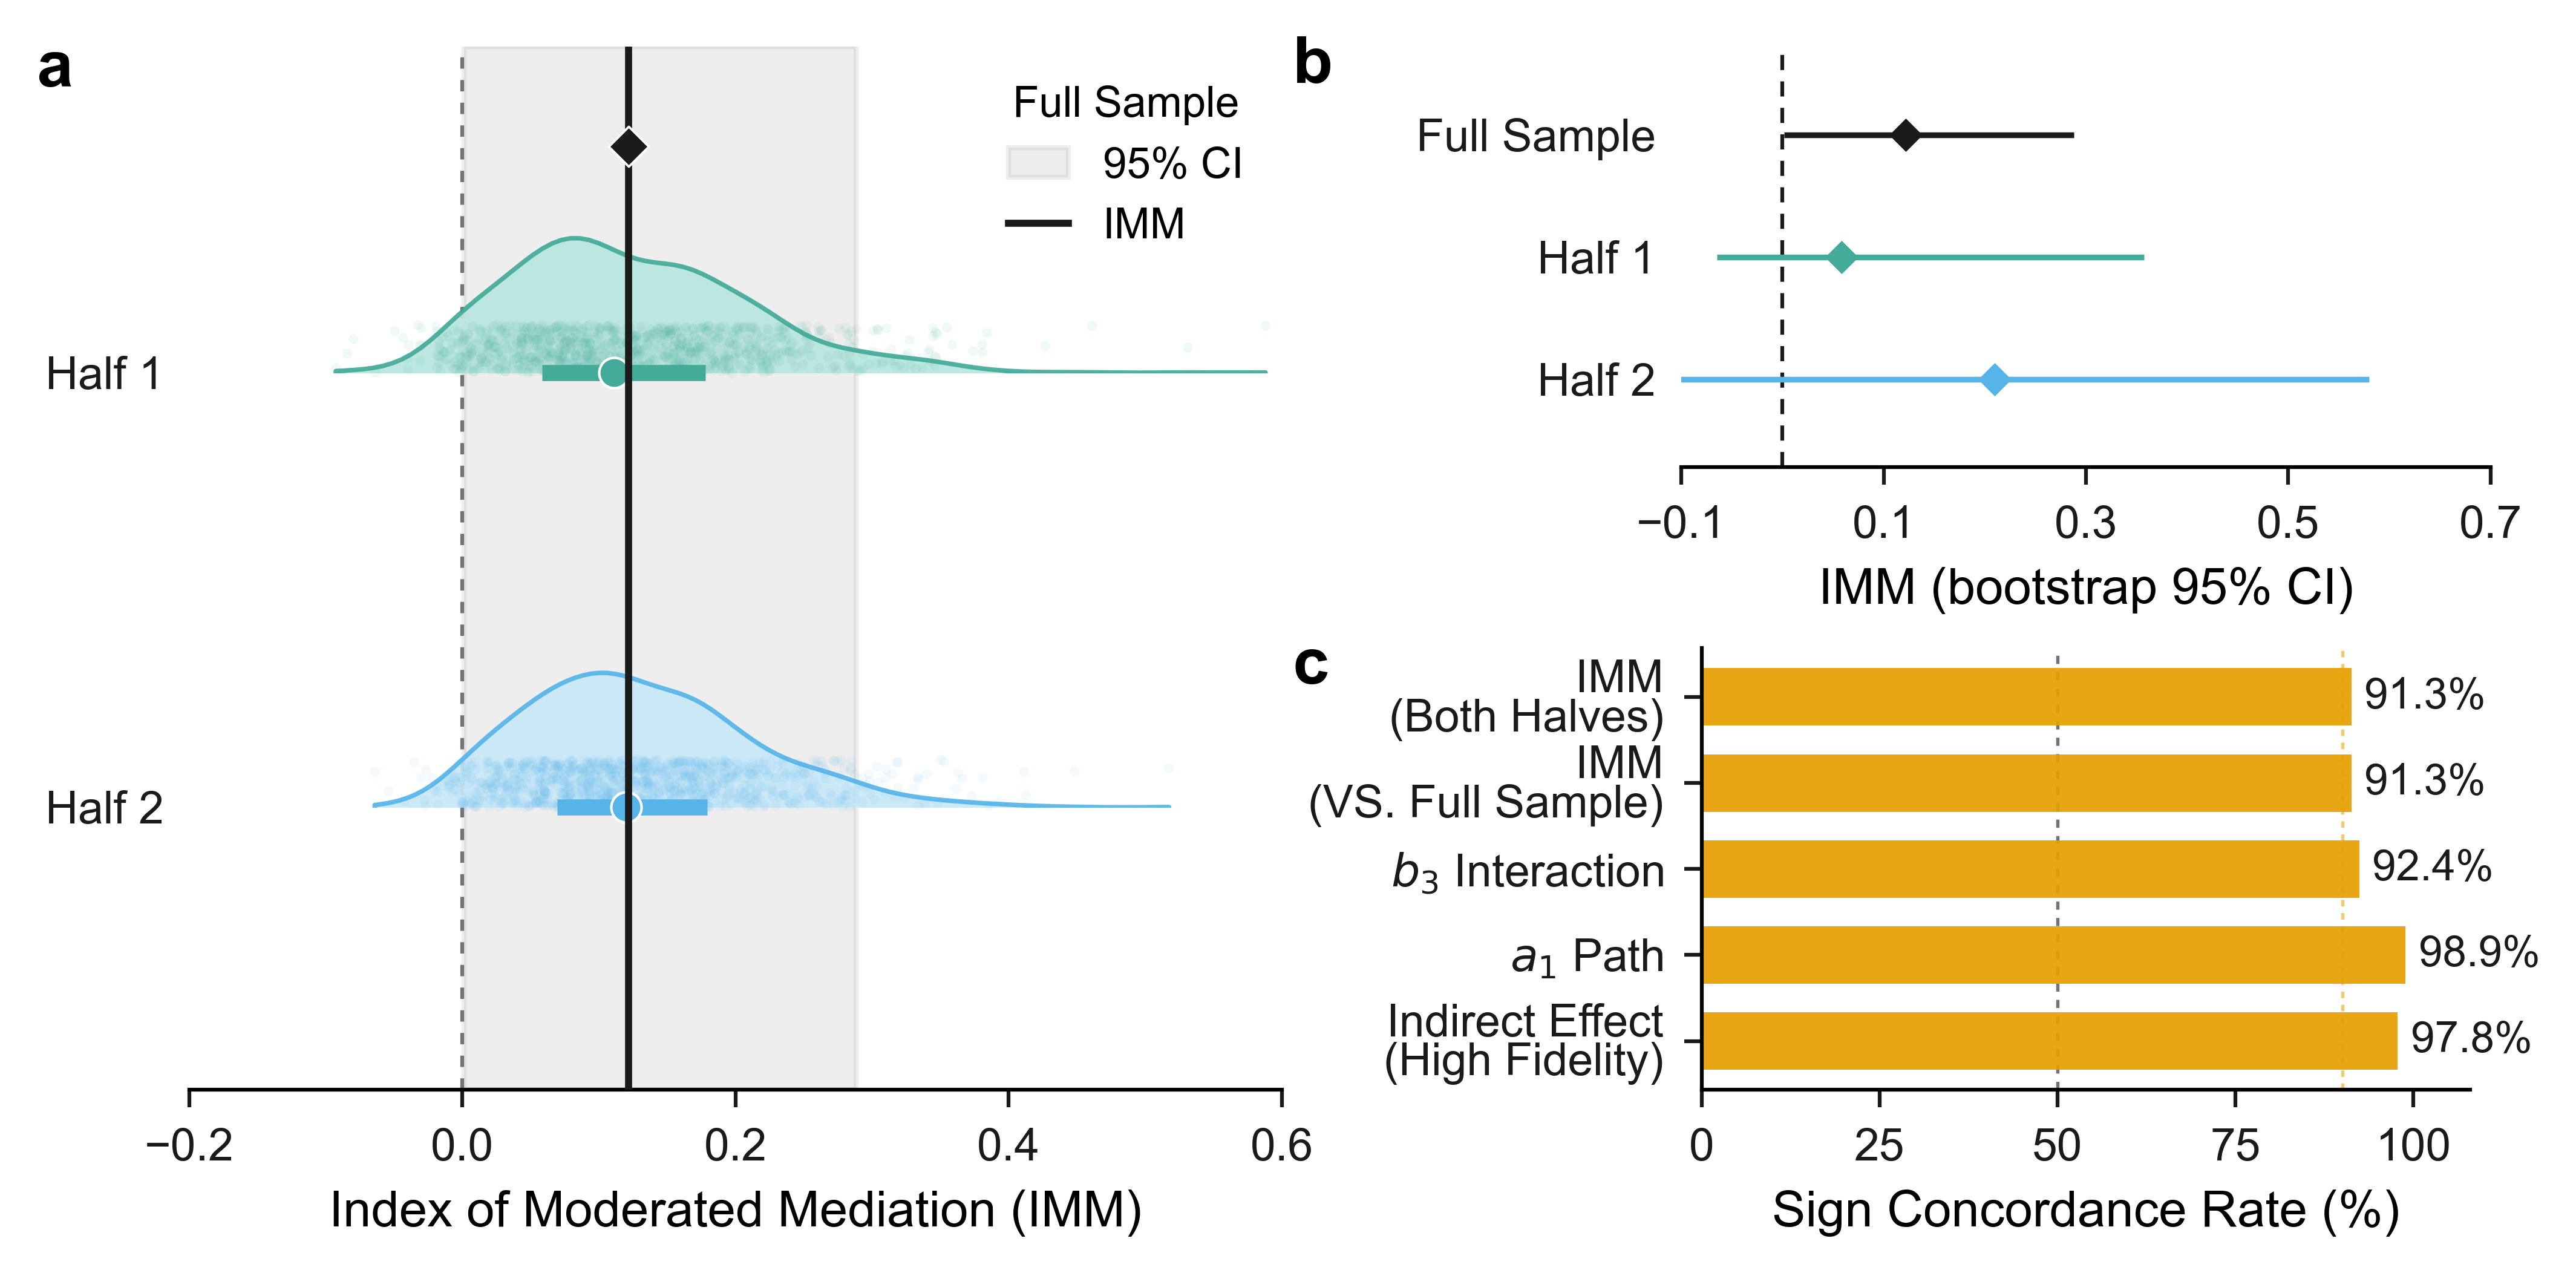

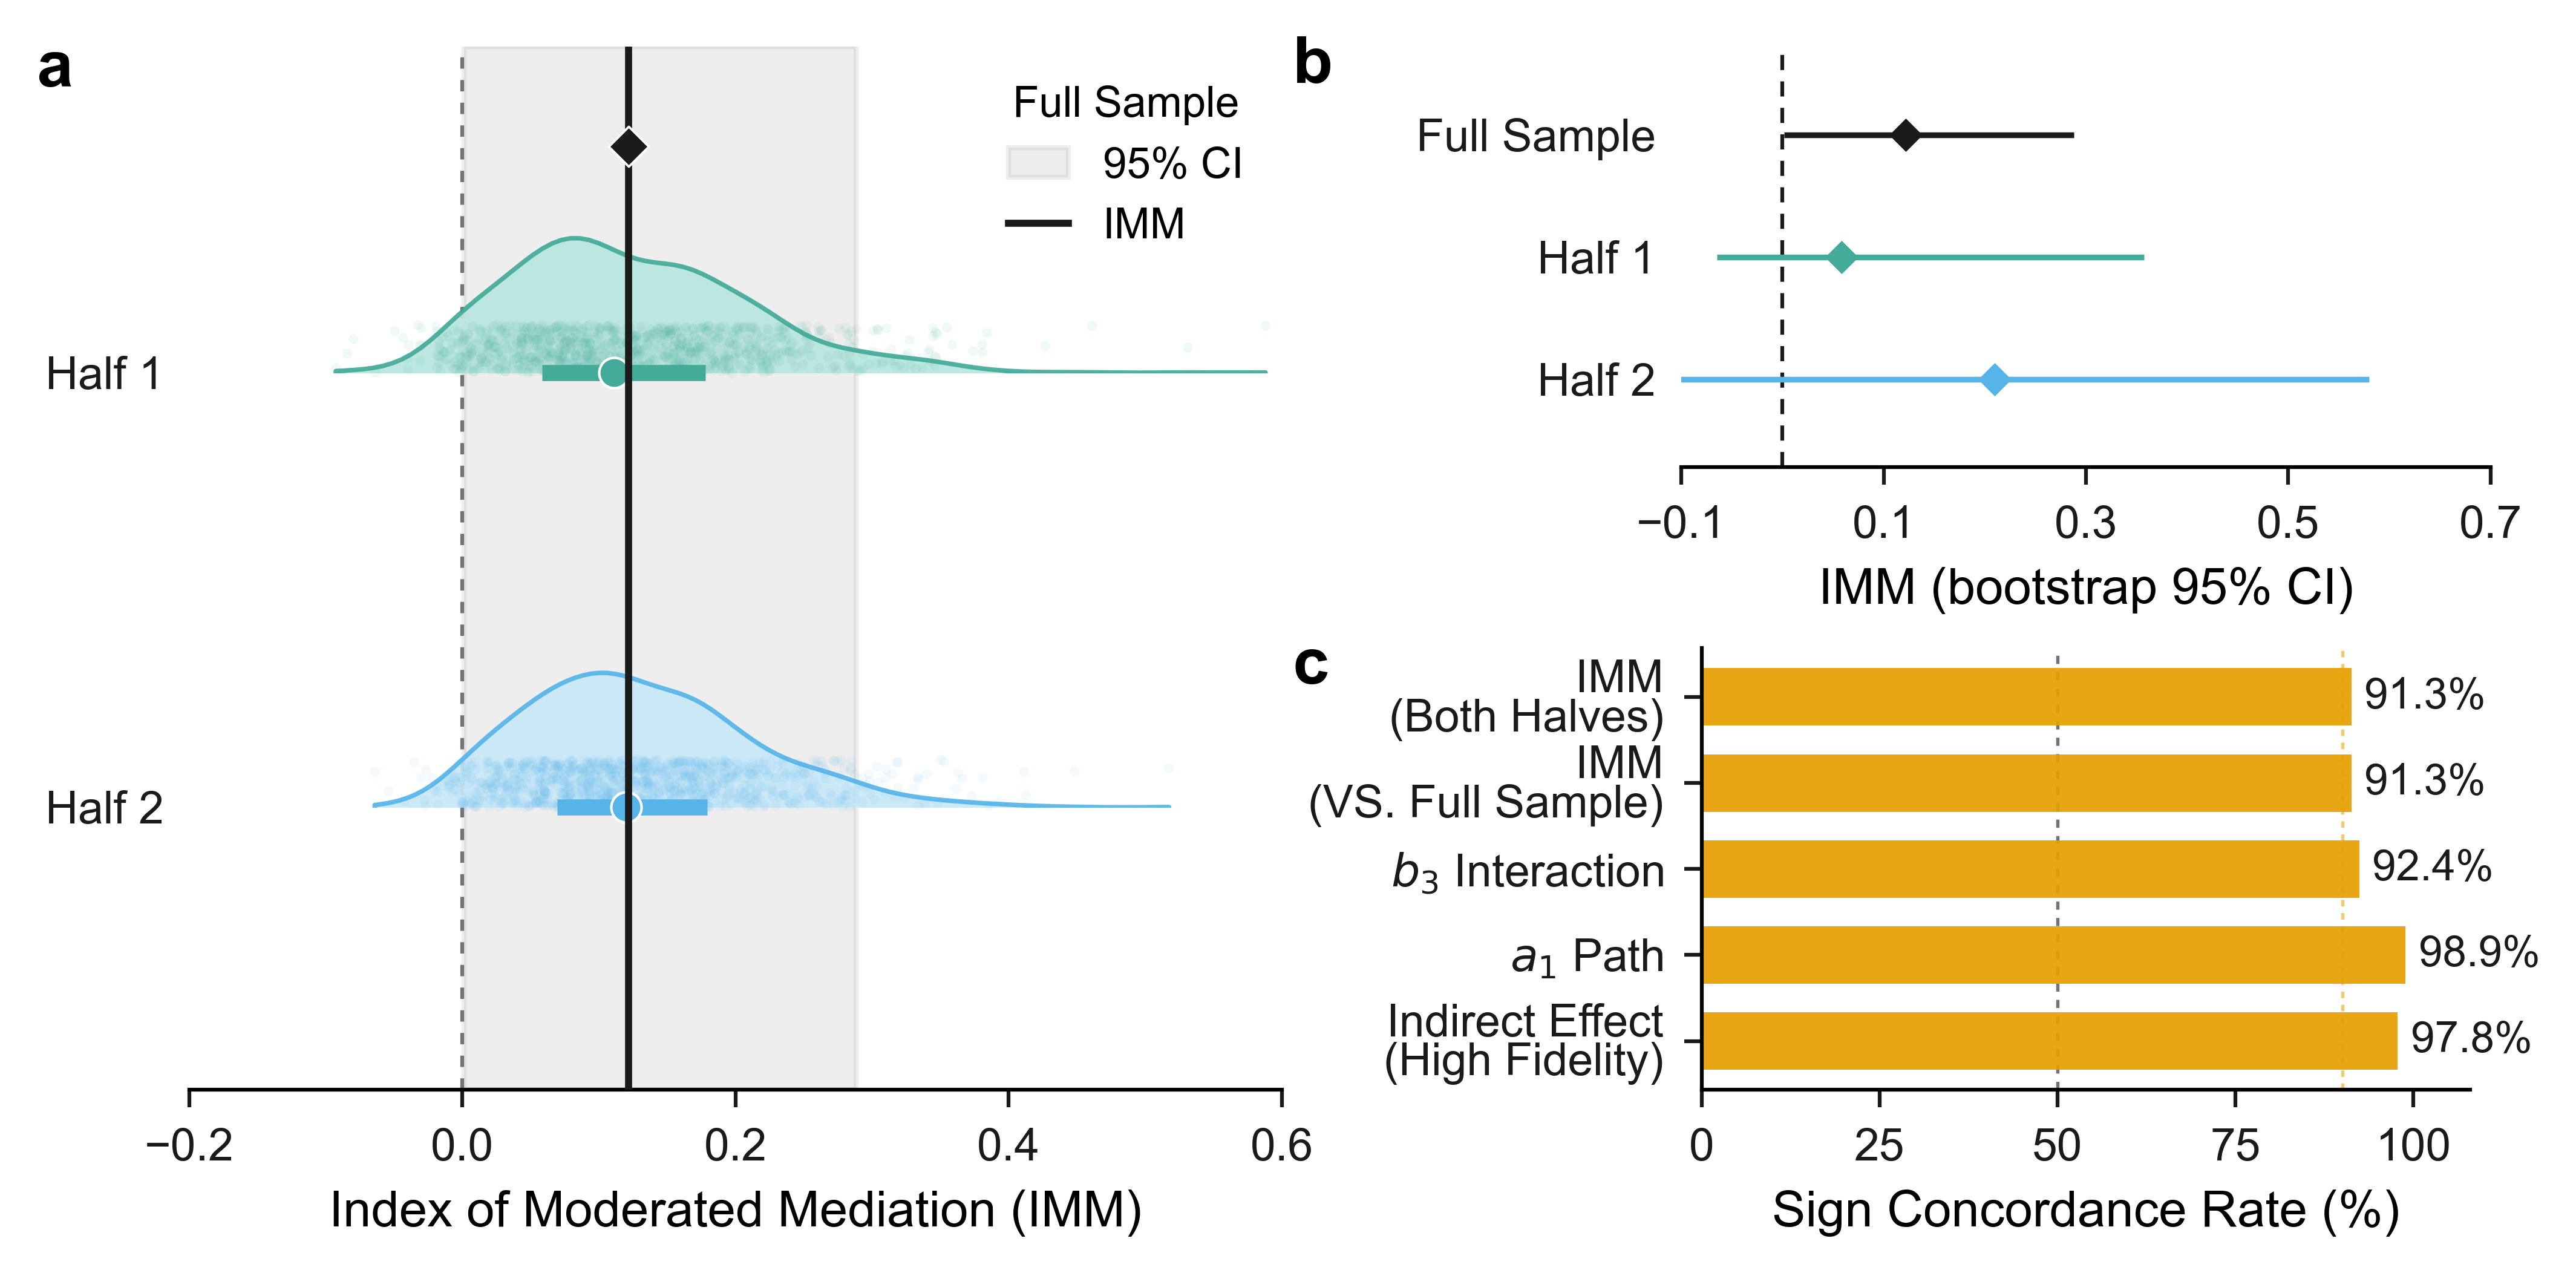

In [2]:
%matplotlib inline

df_sh = load_analysis_df()
sh_result = split_half_validate_panel_e(df_sh, seed=42, n_repeated=1000, n_boot=5000)
print_split_half_supplement(sh_result)
save_split_half_supplement(sh_result, RESULTS_DIR)
fig_sh = plot_split_half_supplement(sh_result, show=True, export=True, out_dir=FIGURES_DIR)
